# 01 — Load and multiview embed

Tutorial on the demo NanoC&T-style object (`acet` + `meth` layers).

**Goal:** filter → multiview spectral → drop depth-correlated component → knn → leiden → UMAP.

See `demos/README.md` for environment setup (`nix-shell` + sparscit venv).


In [10]:
from pathlib import Path
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import sparscit as sc

sc.set_defaults(n_jobs=-1, figsize=(6, 5))
path = "../epigenetic_landscape_analysis_notebooks/demos/data/demo.h5ad"
print("data:", path)


data: ../epigenetic_landscape_analysis_notebooks/demos/data/demo.h5ad


In [11]:
adata = ad.read_h5ad(path)
adata.obs["exclude"] = adata.obs["exclude"].astype(bool)
adata.var["exclude"] = adata.var["exclude"].astype(bool)
adata


AnnData object with n_obs × n_vars = 5000 × 27524
    obs: 'acet_total_counts', 'acet_log_total_counts', 'meth_total_counts', 'meth_log_total_counts', 'exclude'
    var: 'acet_total_counts', 'acet_log_total_counts', 'meth_total_counts', 'meth_log_total_counts', 'chr', 'start', 'end', 'exclude'
    layers: 'acet', 'meth'

In [12]:
# Count filters (tutorial thresholds). return_purged=True drops excluded cells/bins.
adata = sc.tl.filter(
    adata,
    layers=["acet", "meth"],
    min_obs_counts=[30, 20],
    min_var_counts=[5, 3],
    return_purged=True,
)
# Spectral requires no all-zero features
keep = (adata.layers["acet"].sum(0).A1 > 0) & (adata.layers["meth"].sum(0).A1 > 0)
adata = adata[:, keep].copy()
print(adata.shape)


(4970, 21925)


In [13]:
# Multiview spectral (SnapATAC2-style), both modalities
eigs = sc.em.multiview_spectral(
    adata, layers=["acet", "meth"], n_components=15, random_seed=0
)
print("top eigenvalues:", np.round(eigs[:5], 4))


top eigenvalues: [1.     0.0293 0.0281 0.0278 0.0275]


In [14]:
# Drop embedding axis most correlated with total depth (|ρ| > 0.6)
depth = (
    adata.obs["acet_total_counts"].to_numpy()
    + adata.obs["meth_total_counts"].to_numpy()
)
emb = adata.obsm["X_multi_spectral"]
cors = [np.corrcoef(emb[:, i], depth)[0, 1] for i in range(emb.shape[1])]
i = int(np.argmax(np.abs(cors)))
print(f"strongest depth PC: {i}, ρ={cors[i]:.3f}")
if abs(cors[i]) > 0.6:
    sc.tl.remove_pc(adata, "X_multi_spectral", i)


strongest depth PC: 0, ρ=0.927


In [15]:
sc.gr.knn(adata, "X_multi_spectral", n_neighbors=15)
sc.gr.leiden(adata, resolution=1.0, random_seed=0)
sc.em.umap(adata, "X_multi_spectral")
print("clusters:", adata.obs["leiden"].nunique())


clusters: 13


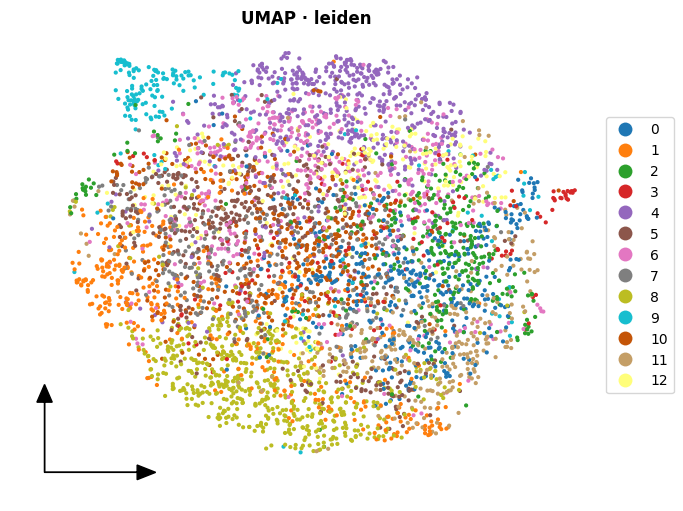

In [16]:
sc.pl.embedding2d(adata, "X_umap", "leiden", size=4, title="UMAP · leiden")
plt.show()


In [17]:
# Optional: save intermediate for faster re-runs of later notebooks
out = Path("../epigenetic_landscape_analysis_notebooks/demos/data") / "demo_embedded.h5ad"
out.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(out, compression="gzip")
print("wrote", out.resolve())


wrote /home/aleksander-work/Dokument/work11/epigenetic_landscape_analysis_notebooks/demos/data/demo_embedded.h5ad
